<a href="https://colab.research.google.com/github/Cordova-2/estadisticainferencial2026A/blob/main/unidad1_problemario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problema 1
Un profesor intenta mostrar a sus estudiantes la importancia de los exámenes cortos, aun cuando el 90% de la calificación final esté determinada por los exámenes parciales. Él cree que cuanto más altas sean las calificaciones de los exámenes cortos, más alta será la calificación final. Seleccionó una muestra aleatoria de 15 estudiantes de su clase con los siguientes datos:

| Promedio de exámenes cortos | Promedio final |
|--------------|--------------|
| 59 | 64 |
| 92 | 84 |
| 72 | 77 |
| 90 | 80 |
| 95 | 77 |
| 87 | 81 |
| 89 | 80 |
| 77 | 84 |
| 76 | 80 |
| 65 | 69 |
| 97 | 83 |
| 42 | 40 |
| 94 | 78 |
| 62 | 65 |
| 91 | 90 |



1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2. Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
12. Realice una tabla ANOVA e interprete el resultado.

In [1]:
import pandas as pd
link_csv= "https://raw.githubusercontent.com/Cordova-2/estadisticainferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_01.csv"
df=pd.read_csv(link_csv)
df

,Promedio_de_examenes_cortos,Promedio_final
0,59,64
1,92,84
2,72,77
3,90,80
4,95,77
5,87,81
6,89,80
7,77,84
8,76,80
9,65,69


1. Se eligieron x=promedio de examnes cortos y y=promedio final, por que va determinar si el promedio de los exámenes cortos ayuda a explicar o predecir la calificación final

In [2]:
x = df["Promedio_de_examenes_cortos"]
y = df['Promedio_final']

2. los datos que aparecen tienen una tendencia ascendente, en general, cuando aumenta el promedio de los exámenes cortos, también va a aumentar el promedio final.

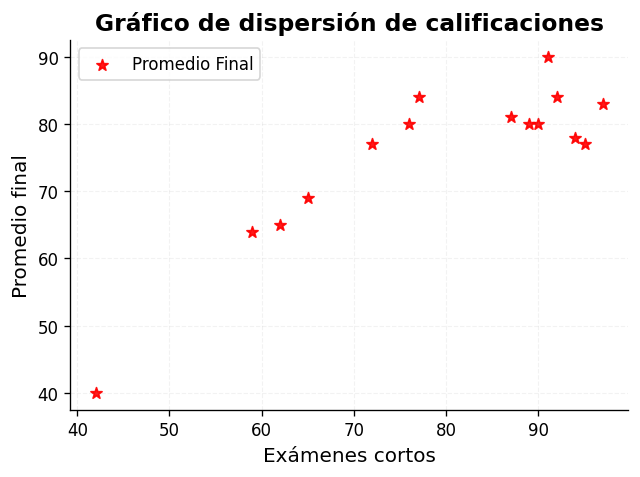

In [3]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker='*',       # forma
    color='red',     # color de los puntos
    edgecolor='red',    # borde de los puntos
    alpha=0.9,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Promedio Final' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de calificaciones',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Exámenes cortos',
    fontsize=12
)

plt.ylabel(
    'Promedio final',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

3. ¿Los datos soportan la suposición de linealidad?
Si, los datos presentan una tendencia aproximadamente lineal y positiva

4. Existe una correlación lineal positiva fuerte entre el promedio de los exámenes cortos y el promedio final

In [4]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.8646
Valor p:  0.0000


6. El valor \(24.526822\) representa el valor estimado de \(Y\) cuando \(X=0\)

In [5]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,24.526822
Promedio_de_examenes_cortos,0.643180


$$
\hat {y} =24.526822+0.64180X
$$
donde
- $\hat{y}$es el promedio final calculado por el modelo
- $X$ es el promedio de examenes cortos

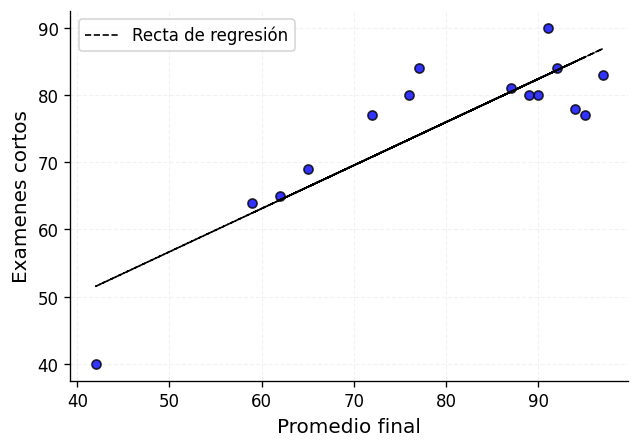

In [6]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Promedio final',
    fontsize=12
)

plt.ylabel(
    'Examenes cortos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

5. Aproximadamente el 74.75% de la variación observada en el promedio final puede ser explicada por la relación lineal con el promedio de los exámenes cortos

In [7]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  74.75%



7. Con un 95% de confianza, la pendiente verdadera de la relación entre el promedio de exámenes cortos y el promedio final se encuentra aproximadamente entre 0.4192 y 0.8671

In [8]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,6.441997,42.611646
Promedio_de_examenes_cortos,0.419219,0.867141


9. Por lo tanto, el supuesto de normalidad de los residuales parece cumplirse.

valor-p (Shapiro) = 0.901827735700704


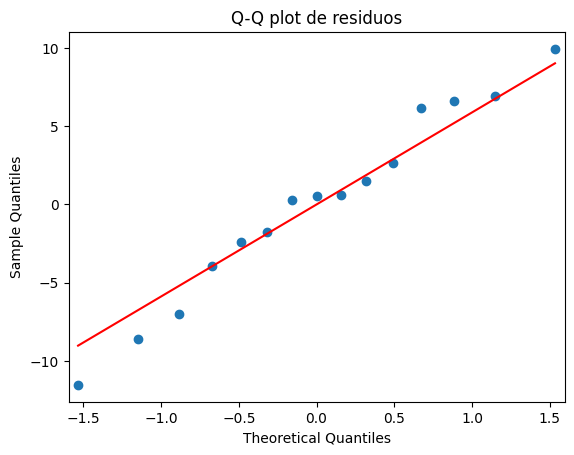

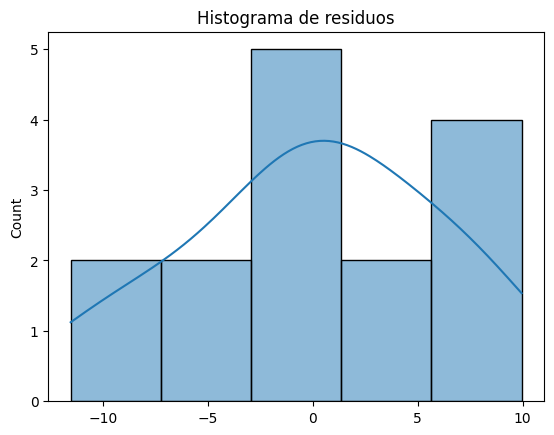

In [9]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

8. Los residuales se encuentran tanto por encima como por debajo de cero y no se observa un patrón curvo, en pocas palabras parecen razonablemente compatibles con un modelo lineal

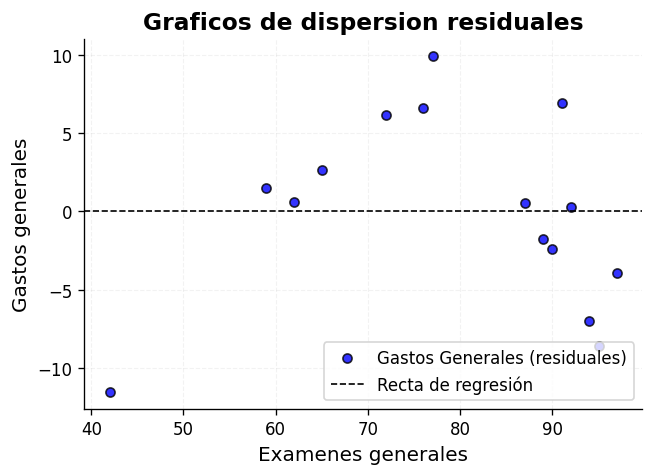

In [10]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Gastos Generales (residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Graficos de dispersion residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Examenes generales',
    fontsize=12
)

plt.ylabel(
    'Gastos generales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
Según el modelo de regresión, un estudiante con promedio de 70 en los exámenes cortos tendría una calificación final esperada de aproximadamente 69.55. Para promedios de 75 y 84, las calificaciones esperadas serían aproximadamente 72.77 y 78.55, respectivamente

Para \(X=70\):
$$ \hat{Y}=24.5268+0.6432(70) $$ $$ \boxed{\hat{Y}=69.55} $$
Para \(X=75\):
$$ \hat{Y}=24.5268+0.6432(75) $$ $$ \boxed{\hat{Y}=72.77} $$
Para \(X=84\):
$$ \hat{Y}=24.5268+0.6432(84) $$ $$ \boxed{\hat{Y}=78.55} $$
	​

10. el supuesto de varianza constante de los residuales parece cumplirse, asi que no hay heterocedasticidad

In [11]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2289



12. En la tabla ANOVA se logra ver que el modelo de regresión es estadísticamente significativo, por lo tanto, existe evidencia de una relación lineal significativa entre el promedio de los exámenes cortos y el promedio final

In [12]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Promedio_final ~ Promedio_de_examenes_cortos', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Promedio_de_examenes_cortos,1.0,1538.228959,1538.228959,38.492412,0.000032
Residual,13.0,519.504375,39.961875,NaN,NaN


### Problema 2
William Hawkins, vicepresidente de personal de la International Motors, trabaja en la relación entre el salario de un trabajador y el porcentaje de ausentismo. Hawkins dividió el intervalo de salarios de International en 12 grados o niveles (1 es el menor grado, 12 el más alto) y después muestreó aleatoriamente a un grupo de trabajadores. Determinó el grado de salario de cada trabajador y el número de días que ese empleado había faltado en los últimos 3 años.

| Categoría de salario | 11 | 10 | 8  | 5  | 9  | 7  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 18 | 17 | 29 | 36 | 11 | 28 | 35 |

| Categoría de salario | 11 | 8  | 7  | 2  | 9  | 8  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 14 | 20 | 32 | 39 | 16 | 31 | 40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [13]:
import pandas as pd
link_csv= "https://raw.githubusercontent.com/Cordova-2/estadisticainferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_02.csv"
df=pd.read_csv(link_csv)
df

,Categoría_salario,ausencias
0,11,18
1,10,17
2,8,29
3,5,36
4,9,11
5,7,28
6,3,35
7,11,14
8,8,20
9,7,32


1. Se eligio estas variables con este acomodo para ver si existe una relación entre el grado de salario de un trabajador y la cantidad de días que se ausenta, ya que el salario depende de los dias aunsentados

In [14]:
x = df["ausencias"]
y = df['Categoría_salario']

2. Se observa una tendencia negativa ya que si aumenta la categoría de salario, el número de ausencias tiende a disminuir

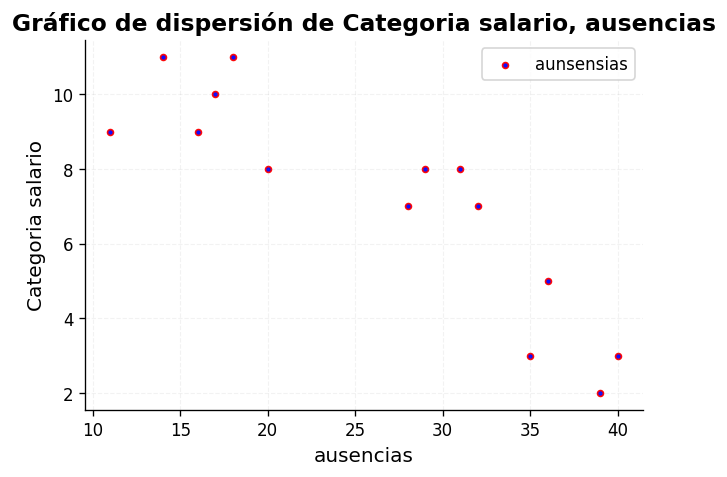

In [15]:
import matplotlib.pyplot as plt
 # Datos

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker='.',       # forma
    color='blue',     # color de los puntos
    edgecolor='red',    # borde de los puntos
    alpha=0.95,            # transparencia
    s=50,                 # tamaño de los puntos
    label='aunsensias' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de Categoria salario, ausencias',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'ausencias',
    fontsize=12
)

plt.ylabel(
    'Categoria salario',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.70,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.5, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

3. ¿Los datos soportan la suposición de linealidad? Los datos sí soportan la suposición de linealidad, por lo que si se puede utilizar un modelo de regresión lineal.

4. El valor \(r=-0.8801\) indica una correlación lineal negativa fuerte entre las variables de salario y las ausencias

In [16]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.8801
Valor p:  0.0000


In [17]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,14.058843
ausencias,-0.261814


$$
\hat {y} =14.058843+0.261814X
$$
donde
- $\hat{y}$es la categoria de salario
- $X$ es el numero de ausensias

6. Esto significa que por cada aumento de una categoría salarial, el número de ausencias esperado disminuye aproximadamente 2.96 días, según el modelo

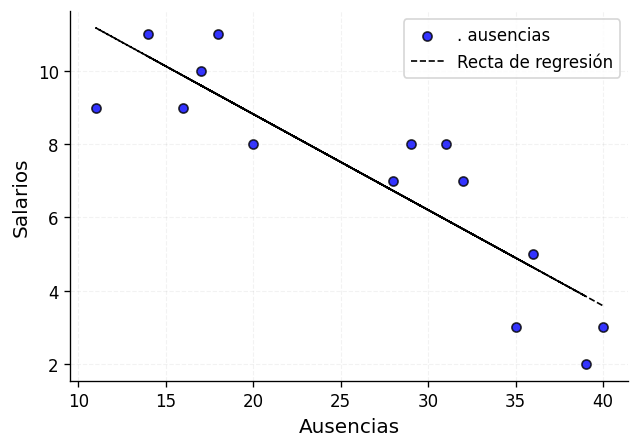

In [18]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='. ausencias' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Ausencias',
    fontsize=12
)

plt.ylabel(
    'Salarios',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

5. El modelo de regresión explica que el 77.46% de la variación observada en el número de ausencias mediante la categoría de salario

In [19]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  77.46%



7. Como el intervalo no contiene el cero, existe evidencia de que la pendiente es negativa y asi se ve que existe una relación lineal negativa entre categoría salarial y ausencias

In [20]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,11.587445,16.530241
ausencias,-0.350638,-0.172989


9. N o se puede afirmar que los residuales no tengan una distribución normal, asi que el supuesto de normalidad de los residuales parece cumplirse

valor-p (Shapiro) = 0.4172971767713699


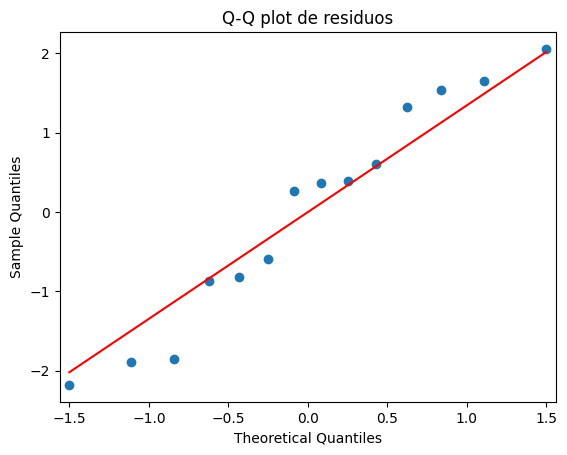

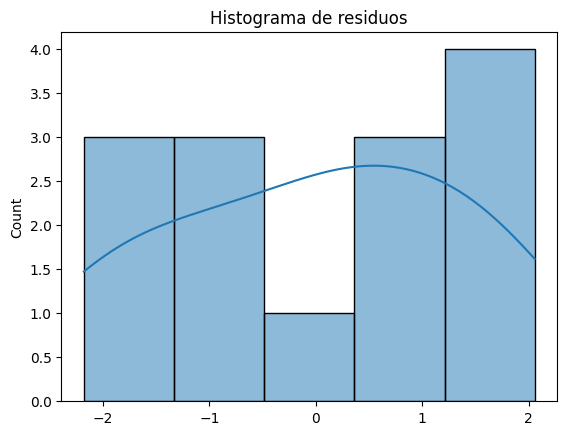

In [21]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

10. el supuesto de homocedasticidad parece cumplirse

In [22]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.8955



11. 20 está dentro del intervalo observado de ausencias, que va de 11 a 40.

$$ \hat Y=14.0588-0.2618(20) $$ $$ \hat Y=8.8226 $$  

Para un trabajador con 20 ausencias, el modelo estima una categoría salarial de aproximadamente 8.82

30 también está dentro del rango observado.

$$ \hat Y=14.0588-0.2618(30) $$ $$ \hat Y=6.2044 $$
Para un trabajador con 30 ausencias, la categoría salarial esperada es de 6.2044

Extrapolación de 45 ausencias

El máximo de ausencias observado es 40

45 está fuera del rango de los datos

$$ \hat Y=14.0588-0.2618(45) $$ $$Y^=2.2762$$

Para un trabajador con 45 ausencias se estima un salario de 2.28


12. La tabla ANOVA indica que el modelo de regresión es significativo asi que existe una relación lineal entre el número de ausencias y la categoría salarial

In [23]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Categoría_salario ~ ausencias', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
ausencias,1.0,87.034348,87.034348,41.243954,0.000033
Residual,12.0,25.322795,2.110233,NaN,NaN


### Problema 3
A menudo, quienes hacen la contabilidad de costos estiman los gastos generales con base en el nivel de producción. En Standard Knitting Co. han reunido información acerca de los gastos generales y las unidades producidas en diferentes plantas.

| Gastos generales | 191 | 170 | 272 | 155 | 280 | 173 | 234 | 116 | 153 | 178 |
|------------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| Unidades        |  40 |  42 |  53 |  35 |  56 |  39 |  48 |  30 |  37 |  40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.


In [24]:
import pandas as pd
link_csv= "https://raw.githubusercontent.com/Cordova-2/estadisticainferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_03.csv"
df=pd.read_csv(link_csv)
df

,Gastos_generales,Unidades
0,191,40
1,170,42
2,272,53
3,155,35
4,280,56
5,173,39
6,234,48
7,116,30
8,153,37
9,178,40


1. Las unidades producidas son la variable independiente porque queremos ver si el nivel de producción ayuda a explicar los gastos generales

In [25]:
x = df["Unidades"]
y = df['Gastos_generales']

2. Se graficaron los ( X y Y ) y se observo gráfico que lleva una tendencia ascendente

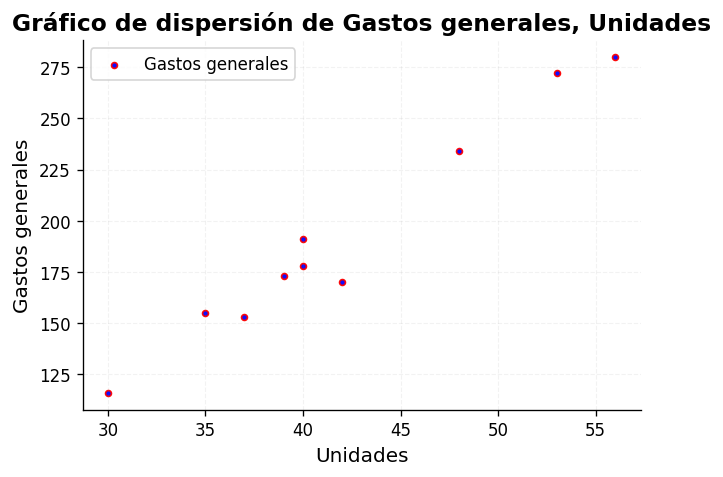

In [26]:
import matplotlib.pyplot as plt
 # Datos

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker='.',       # forma
    color='blue',     # color de los puntos
    edgecolor='red',    # borde de los puntos
    alpha=0.95,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Gastos generales' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de Gastos generales, Unidades',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Unidades',
    fontsize=12
)

plt.ylabel(
    'Gastos generales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.70,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.5, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

3. ¿ los datos soportan la suposicion de linealidad? Lo visto en el grafico de dispersion si y que se vio que si existe una tendencia, los datos si soportan la suposicion de linealidad

4. Se logra observar que si existe una correlacion lineal positiva entre el nivel de unidades y los gastos genrales ya que a mayor cantidad de unidades aunmentan mas los gastos generales

In [27]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9835
Valor p:  0.0000


In [28]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,-80.442857
Unidades,6.491497


$$
\hat {y} =-80.442857+6.491497X
$$
donde
- $\hat{y}$ son los gastos generales
- $X$ son las unidades

6. Despues de obtener la pendiente y el intercepto, se representa el gasto general estimado cuando se producen 0 unidades

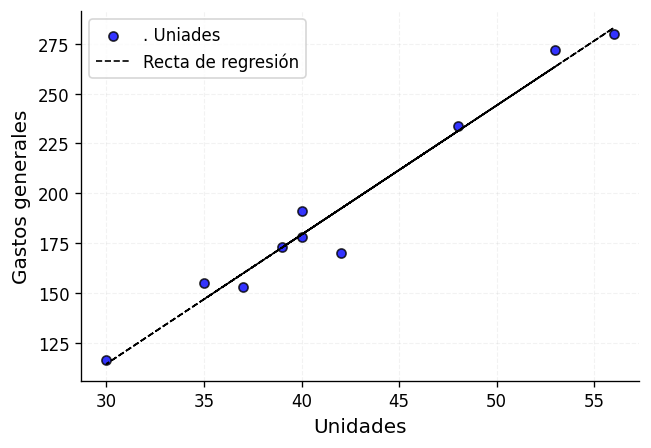

In [29]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='. Uniades' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Unidades',
    fontsize=12
)

plt.ylabel(
    'Gastos generales',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

5. El 96.73% de la variacion de los gastos generales se logra explicar y entender por el nivel de unidades producidas por el modelo lineal

In [30]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  96.73%



7. Como se indica que se tiene un 95% de confianza, se logro entender un incremento real de los gastos generales por cada unidad producida se encuentra entre 518450, 7.464543 y dado que no se tiene una negatividad se ve que la produccion impacta en los costos

In [31]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,-121.986373,-38.899341
Unidades,5.518450,7.464543


9. Como p es > 0.05 no se rechaza la hipotesis nula ya que los residuales siguen una distribucion normal

valor-p (Shapiro) = 0.22045077017698533


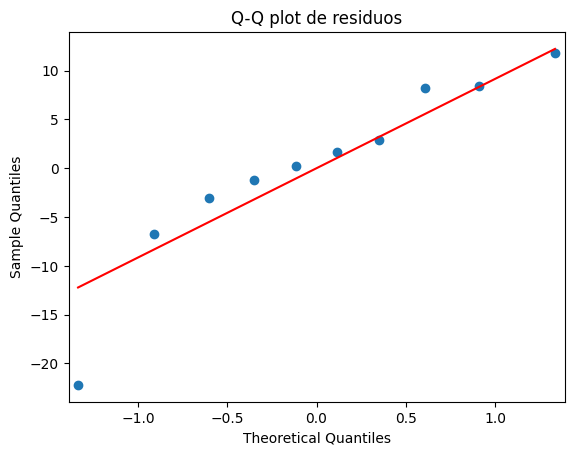

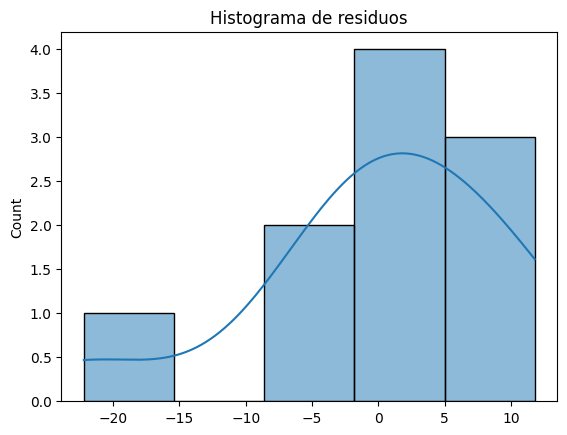

In [32]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

8. Se observo que en el grafico de residuales se distribuyeron de manera aleatoria y sin algun patron ala vista al rededor de 0, a lo que yo observe es que se logran cumplir los supuestos de linealidad y homocedasticidad

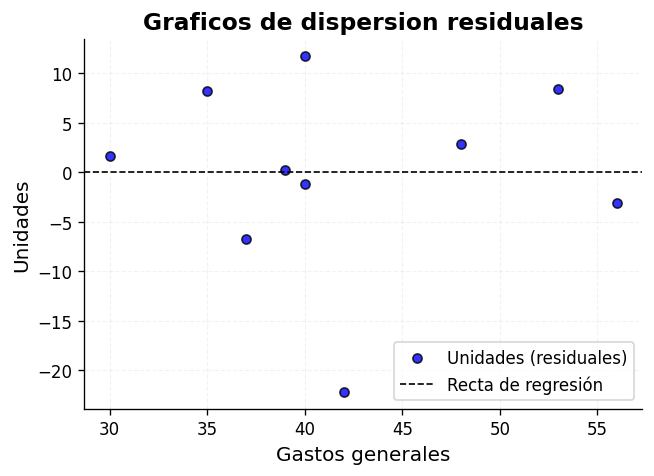

In [33]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Unidades (residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Graficos de dispersion residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Gastos generales',
    fontsize=12
)

plt.ylabel(
    'Unidades',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.5, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

10. Aqui el valor de p es > 0.05 y asi se indica que la homoceasidad se acepta

In [34]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.9858



11. Primera interpolación fue de 35 unidades

35 se encuentra dentro del rango

$$ \hat Y=-80.4429+6.4915(35) $$ $$Y^=146.759$$

Si se producen 35 unidades, el modelo estima unos gastos generales de 146.76

Segunda interpolación fue de 45 unidades

45 también está dentro del rango de 30 a 56.

$$ \hat Y=-80.4429+6.4915(45) $$ $$Y^=211.6745$$
para una producción de 45 unidades, los gastos generales esperados son de 211.67

Extrapolación sra de 60 unidades

60 está fuera del rango observado, ya que el máximo fue 56.

$$ \hat Y=-80.4429+6.4915(60) $$ $$Y^=309.0469$$

Si se producen 60 unidades, se espera gastos generales de 309.05
	​



12. El valor de p es menor que 0.05 y asi que se logra ver que el modelo de regresion lineal es signficativo para poder explicar apartir de las unidades producidas para los gastos genrales

In [35]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Gastos_generales ~ Unidades', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Unidades,1.0,24778.042517,24778.042517,236.669535,3.167080e-07
Residual,8.0,837.557483,104.694685,NaN,NaN


### Problema 4
Las ventas de línea blanca varían según el estado del mercado de casas nuevas: cuando las ventas de casas nuevas son buenas, también lo son las de lavaplatos, lavadoras de ropa, secadoras y refrigeradores.
Una asociación de comercio compiló los siguientes datos históricos (en miles de unidades) de las ventas de línea blanca y la construcción de casas.

| Construcción de casas (miles) | Ventas de línea blanca (miles) |
|-------------------------------|--------------------------------|
| 2.0                           | 5.0                            |
| 2.5                           | 5.5                            |
| 3.2                           | 6.0                            |
| 3.6                           | 7.0                            |
| 3.7                           | 7.2                            |
| 4.0                           | 7.7                            |
| 4.2                           | 8.4                            |
| 4.6                           | 9.0                            |
| 4.8                           | 9.7                            |
| 5.0                           | 10.0                           |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [36]:
import pandas as pd
link_csv= "https://raw.githubusercontent.com/Cordova-2/estadisticainferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_04.csv"
df=pd.read_csv(link_csv)
df

,Construcción_de_casas,Ventas_de_línea_blanca
0,2.0,5.0
1,2.5,5.5
2,3.2,6.0
3,3.6,7.0
4,3.7,7.2
5,4.0,7.7
6,4.2,8.4
7,4.6,9.0
8,4.8,9.7
9,5.0,10.0


1. Se distribuyeron de esta manera las variables ya que esto se debe a que las ventas de línea blanca dependen, en cierta medida, de la cantidad de casas nuevas que se construyen

In [37]:
x = df["Construcción_de_casas"]
y = df['Ventas_de_línea_blanca']

2. El gráfico muestra una relación positiva entre la construcción de casas y las ventas de línea blanca ya que los puntos van hacia arriba a como aumenta x

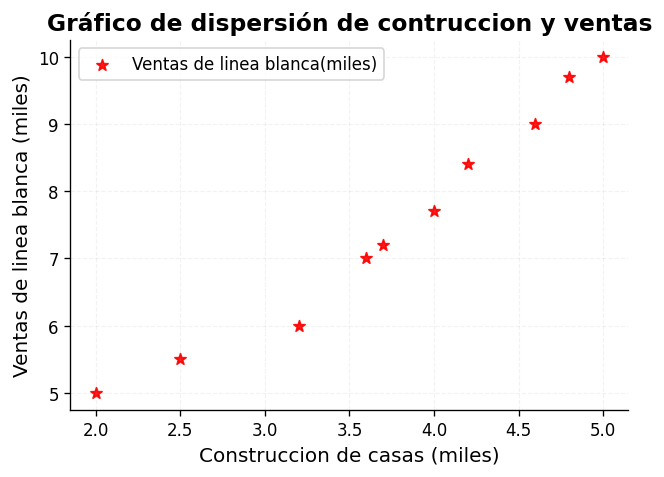

In [38]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker='*',       # forma
    color='red',     # color de los puntos
    edgecolor='red',    # borde de los puntos
    alpha=0.9,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Ventas de linea blanca(miles)' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de contruccion y ventas',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construccion de casas (miles)',
    fontsize=12
)

plt.ylabel(
    'Ventas de linea blanca (miles)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

3. ¿Los datos soportan la suposición de linealidad?

Si, ya que los datos parecen seguir una tendencia aproximadamente recta y ascendente

4. El resultado está muy cerca de 1 por lo que existe una correlación positiva muy fuerte entre las dos variables

In [39]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9808
Valor p:  0.0000


In [40]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,1.016760
Construcción_de_casas,1.737564


$$
\hat {y} =1.01670+1.737564X
$$
donde
- $\hat{y}$ son las ventas de linea blanca
- $X$ son las cpntrucciones de casas

6. La pendiente es 1.7376, esto quiere decir que por cada aumento de 1 mil casas construidas, las ventas de línea blanca aumentan en promedio de 1.74 de unidades

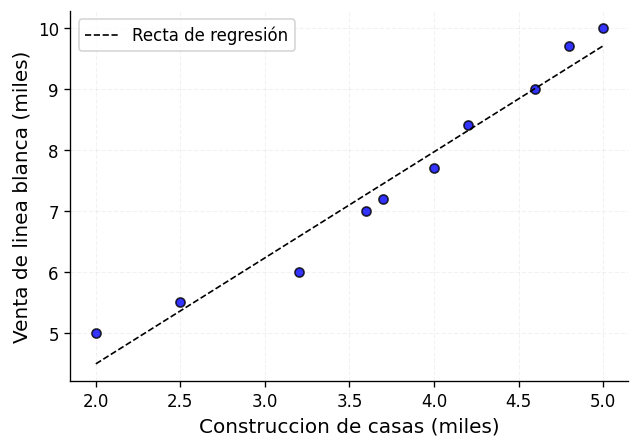

In [41]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construccion de casas (miles)',
    fontsize=12
)

plt.ylabel(
    'Venta de linea blanca (miles)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

5. El 96.19% de la variación en las ventas de línea blanca puede ser entendida por la construcción de casas nuevas

In [42]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  96.19%



7. Con un 95% de confianza, la pendiente verdadera se encuentra aproximadamente entre 1.46 y 2.02, como el intervalo no contiene el cero se puede afirmar que la relación entre construcción de casas y ventas de línea blanca es positiva

In [43]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,-0.074848,2.108368
Construcción_de_casas,1.455693,2.019435


9. Los residuales tiene un comportamiento compatible con una distribución normal

valor-p (Shapiro) = 0.8463507249054649


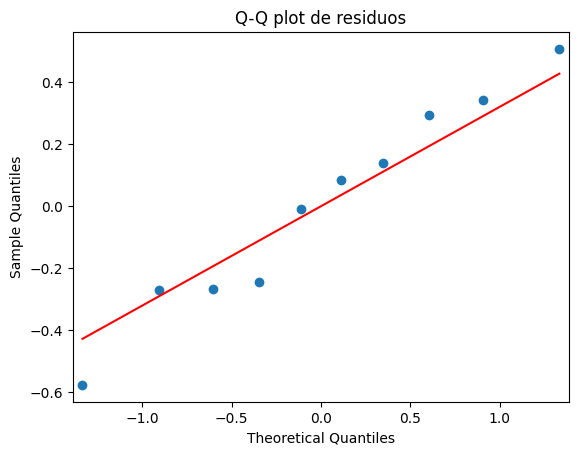

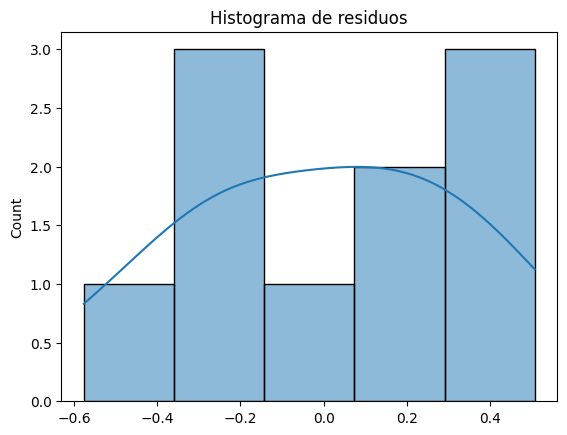

In [44]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

8. Los residuales se encuentran tanto arriba como abajo de cero y no forman una figura o patron

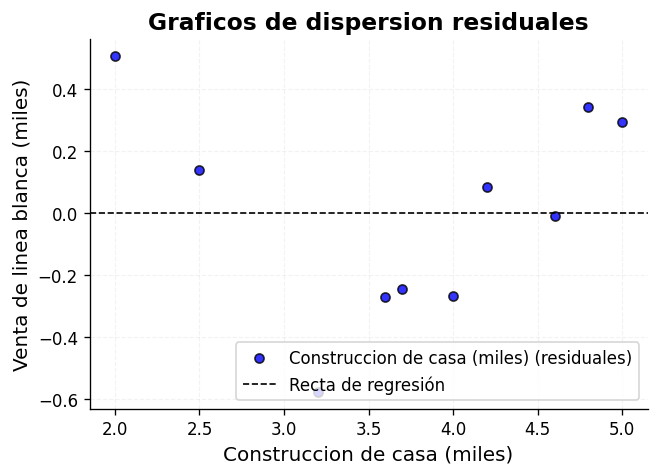

In [45]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Construccion de casa (miles) (residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Graficos de dispersion residuales',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construccion de casa (miles)',
    fontsize=12
)

plt.ylabel(
    'Venta de linea blanca (miles)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

10. Los residuales mantienen una variación estable por lo que no se observa un problema de heterocedasticidad

In [46]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.1581



11. Interpolación 1 sera X = 3
$$ \hat Y=1.0168+1.7376(3) $$ $$y=6.2295$$
6.23 miles de unidades de ventas

X = 4.5
$$ \hat Y=1.0168+1.7376(4.5) $$ $$ \hat Y=8.8358 $$
 8.84 miles de unidades

Extrapolación: X = 6
$$ \hat Y=1.0168+1.7376(6) $$ $$ \hat Y=11.4421 $$
11.44 miles de unidades


12. Existe una relación lineal significativa entre la construcción de casas y las ventas de línea blanca

In [47]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Ventas_de_línea_blanca ~ Construcción_de_casas', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Construcción_de_casas,1.0,25.976581,25.976581,202.069951,5.841003e-07
Residual,8.0,1.028419,0.128552,NaN,NaN


### Problema 5
William C. Andrews, consultor de comportamiento organizacional de Victory Motorcycles, ha diseñado una prueba para mostrar a los supervisores de la compañía los peligros de sobrevigilar a sus trabajadores.
Un trabajador de la línea de ensamble tiene a su cargo una serie de tareas complicadas. Durante el desempeño del trabajador, un inspector lo interrumpe constantemente para ayudarlo a terminar las tareas.
El trabajador, después de terminar su trabajo, recibe una prueba psicológica diseñada para medir la hostilidad del trabajador hacia la autoridad
(una alta puntuación implica una hostilidad baja). A ocho distintos trabajadores se les asignaron las tareas y luego se les interrumpió para darles instrucciones útiles un número variable de veces (línea X).
Sus calificaciones en la prueba de hostilidad se dan en el renglón Y.

| número interrupciones al trabajador |  5  | 10  | 10  | 15  | 15  | 20  | 20  | 25  |
|-----------------------------------------|----|----|----|----|----|----|----|----|
| calificación del trabajador en la prueba de hostilidad | 58  | 41  | 45  | 27  | 26  | 12  | 16  |  3  |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [48]:
import pandas as pd
link_csv= "https://raw.githubusercontent.com/Cordova-2/estadisticainferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_05.csv"
df=pd.read_csv(link_csv)
df

,número_interrupciones_al_trabajador,calificación_del_trabajador_en_la_prueba_de_hostilidad
0,5,58
1,10,41
2,10,45
3,15,27
4,15,26
5,20,12
6,20,16
7,25,3


1. Las variables se eligieron asi poe que la calificación del trabajador es la variable que queremos analizar según el número de veces que fue interrumpido

In [49]:
x = df['número_interrupciones_al_trabajador']
y = df['calificación_del_trabajador_en_la_prueba_de_hostilidad']

2. Se observa que los puntos van hacia abajo conforme aumentan las interrupciones

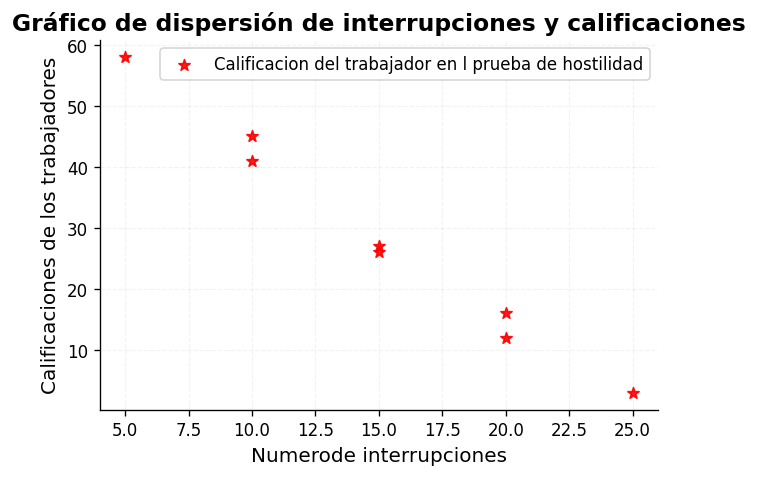

In [50]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker='*',       # forma
    color='red',     # color de los puntos
    edgecolor='red',    # borde de los puntos
    alpha=0.9,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Calificacion del trabajador en l prueba de hostilidad' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de interrupciones y calificaciones',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Numerode interrupciones',
    fontsize=12
)

plt.ylabel(
    'Calificaciones de los trabajadores',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

3. ¿Los datos soportan la suposición de linealidad?
Si, los puntos siguen una tendencia bastante clara y cercana a una línea recta

4. El valor está muy cerca de -1, por lo que existe una relación negativa entre las dos variables

In [51]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.9928
Valor p:  0.0000


In [52]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,70.5
número_interrupciones_al_trabajador,-2.8


$$
\hat {y} =70.5-2.8X
$$
donde
- $\hat{y}$es la calificacion del trabajador  
- $X$ es el numero de interrupciones del trabajador

6. La pendiente es -2.8, esto significa que por cada interrupción adicional, la calificación esperada disminuye aproximadamente 2.8 puntos

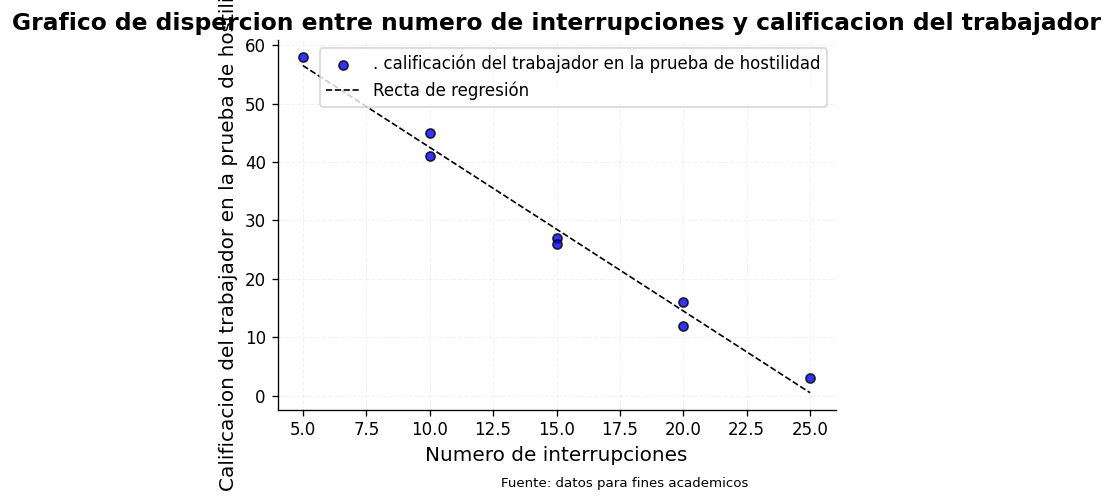

In [53]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='. calificación del trabajador en la prueba de hostilidad' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Grafico de dispercion entre numero de interrupciones y calificacion del trabajador',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Numero de interrupciones',
    fontsize=12
)

plt.ylabel(
    'Calificacion del trabajador en la prueba de hostilidad',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    'Fuente: datos para fines academicos',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

5. El 98.58% de la variación en las calificaciones se debe por el número de interrupciones

In [54]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  98.58%



7. Con un 95% de confianza, la pendiente estaría entre -3.14 y -2.46 aproximadamente, como el intervalo no contiene el 0, se observa que existe una relación negativa entre las interrupciones y la calificación

In [55]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,65.051384,75.948616
número_interrupciones_al_trabajador,-3.136296,-2.463704


9. No hay evidencia suficiente para decir que los residuales no tiene una distribución normal

valor-p (Shapiro) = 0.054816491127669634


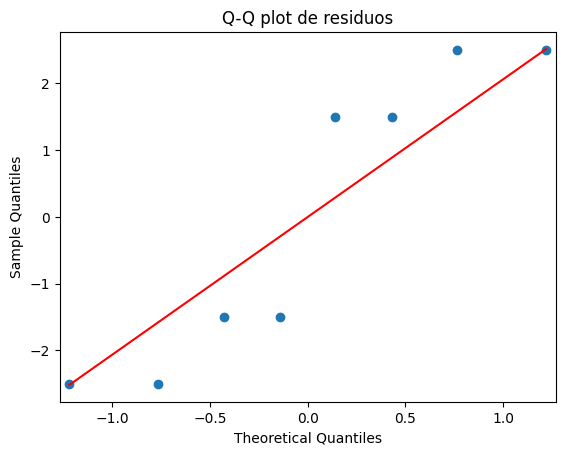

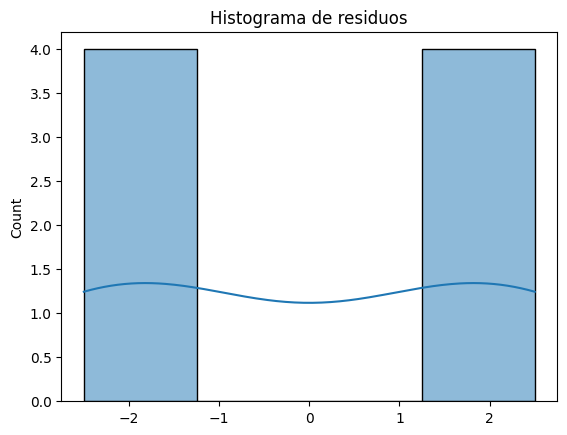

In [56]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

8. Los residuales son pequeños y se encuentran tanto arriba como abajo de cero, asi que se observa una forma curva ni un aumento claro de los errores

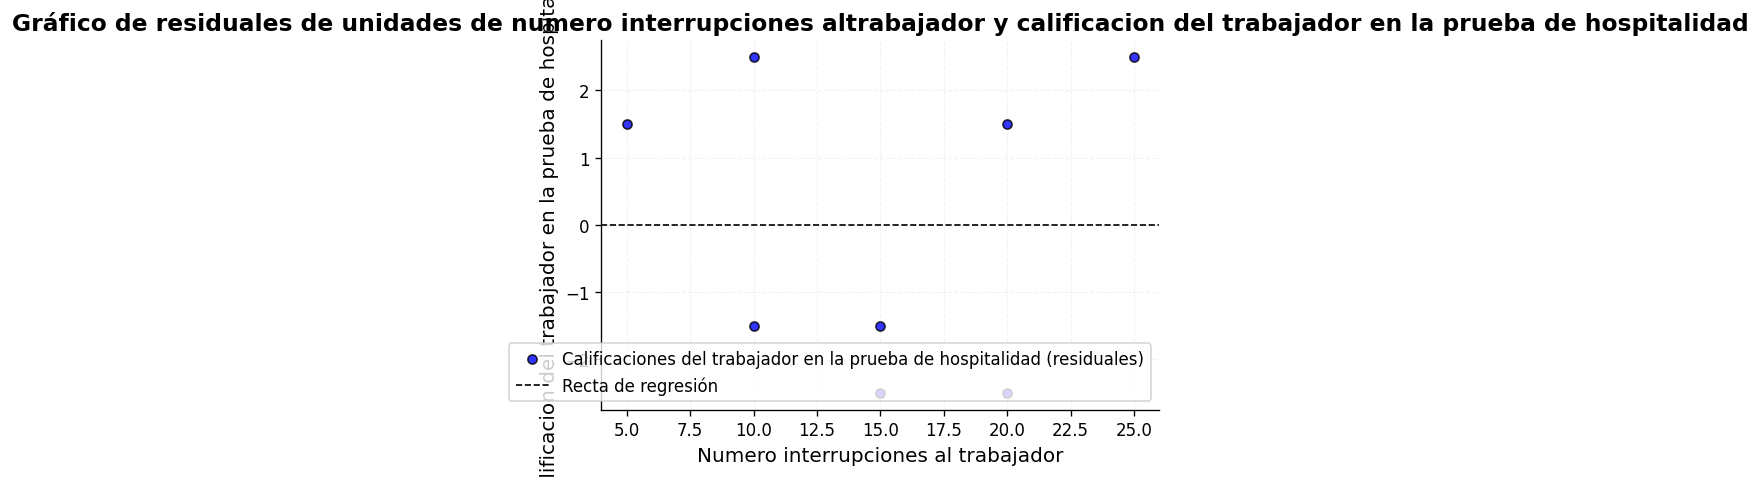

In [57]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Calificaciones del trabajador en la prueba de hospitalidad (residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Gráfico de residuales de unidades de numero interrupciones altrabajador y calificacion del trabajador en la prueba de hospitalidad',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Numero interrupciones al trabajador',
    fontsize=12
)

plt.ylabel(
    'Calificacion del trabajador en la prueba de hospitalidad',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

10. No se observa evidencia de heterocedasticidad

In [58]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2482



11. la primera interpolacion sera de cual seria la calificacion del trbajador si tiene 8 interrupciones
$$ \hat Y=70.5-2.8(8) $$ $$ \hat Y=70.5-22.4 $$ $$Y^=48.1$$
Si un trabajador tiene 8 interrupciones, se estima que obtendría una calificación de 48.1 puntos en la prueba

la segunda interpolacion sera de cual es la calificaion del trabajador si tiene 18 interrupciones
$$ \hat Y=70.5-2.8(18) $$ $$ \hat Y=70.5-50.4 $$ $$Y^=20.1$$
Si un trabajador tiene 18 interrupciones obtendria una calificación de 20.1 puntos

Extrapolación 30 interrupciones

$$ \hat Y=70.5-2.8(30) $$ $$ \hat Y=-13.5 $$
Si se intentara obtener la calificación para un trabajador que recibiera 30 interrupciones, el modelo daría -13.5 puntos



12. Esto indica que existe una relación lineal importante entre el número de interrupciones y la calificación obtenida

In [59]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('calificación_del_trabajador_en_la_prueba_de_hostilidad  ~ número_interrupciones_al_trabajador', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
número_interrupciones_al_trabajador,1.0,2352.0,2352.000000,415.058824,9.090964e-07
Residual,6.0,34.0,5.666667,NaN,NaN
